In [37]:
import numpy as np
import pandas as pd
import scipy.signal as signal
from scipy.signal import butter,filtfilt,windows
import matplotlib.pyplot as plt


In [38]:
emg = pd.read_csv(r"c:/Users/NITISH GUPTA/Downloads/Trial_8 - Copy.csv",skiprows=1)
time=emg.iloc[:,0].values
emg_muscle=emg.iloc[:,1].values
fs=2148

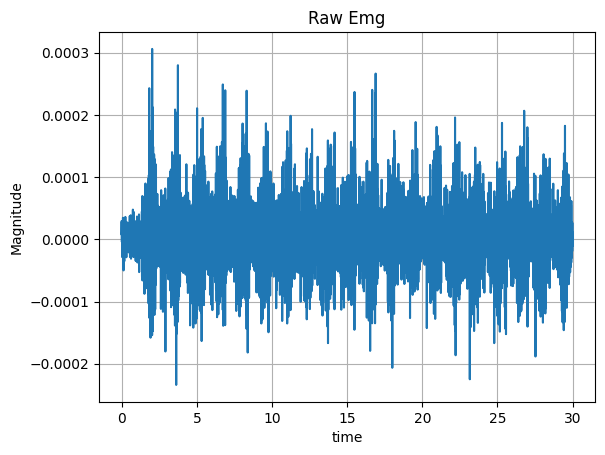

In [39]:
plt.figure()
plt.plot(time,emg_muscle)
plt.xlabel("time")
plt.ylabel("Magnitude")
#volts
plt.title("Raw Emg")
plt.grid()
plt.show()

In [40]:
#FFT 
fft_values = np.fft.fft(emg_muscle)
N = len(emg_muscle)
freqs = np.fft.fftfreq(N,d=1/fs)

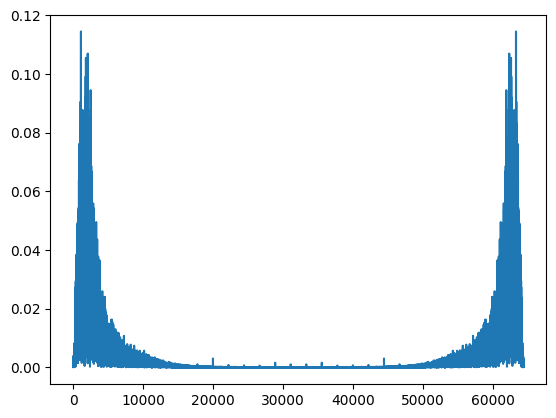

In [41]:
mag = np.abs(fft_values)
plt.plot(mag)

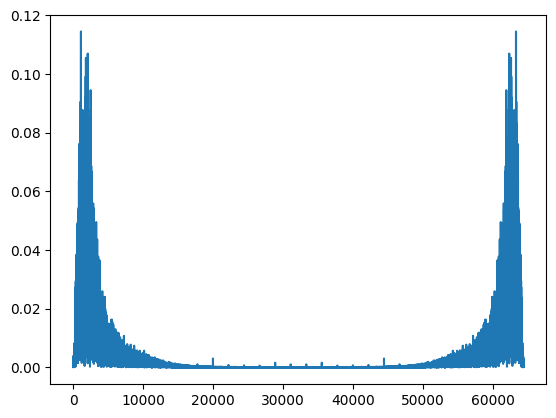

In [42]:
mag = np.abs(fft_values)
plt.plot(mag)

In [43]:
half = N // 2

freqs_half = freqs[:half]
mag_half = mag[ :half] 
magnitude = (np.abs(mag_half))/ N 
magnitude[1:] = 2 * magnitude[1:]

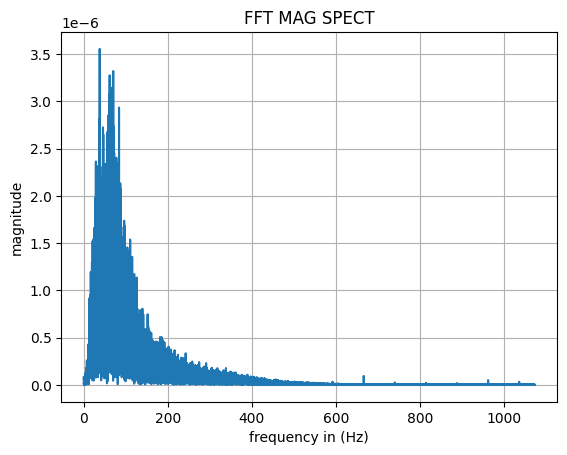

In [44]:
plt.figure()
plt.plot(freqs_half,magnitude)
plt.xlabel("frequency in (Hz)")
plt.ylabel("magnitude")
#volts
plt.title("FFT MAG SPECT")
plt.grid()
plt.show()

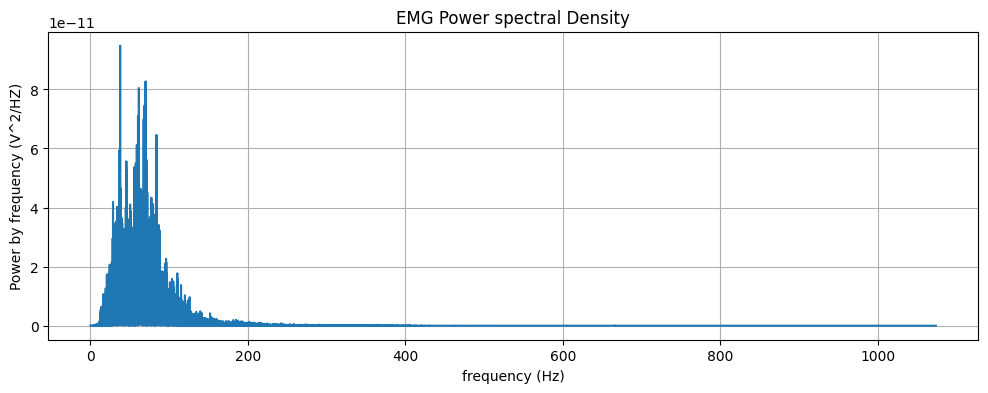

In [45]:
psd = (1/(fs*N)) * np.abs(fft_values[:half])**2


plt.figure(figsize=(12,4))
plt.plot(freqs_half,psd)
plt.xlabel("frequency (Hz)")
plt.ylabel("Power by frequency (V^2/HZ)")
#volts
plt.title("EMG Power spectral Density")
plt.grid()
plt.show()

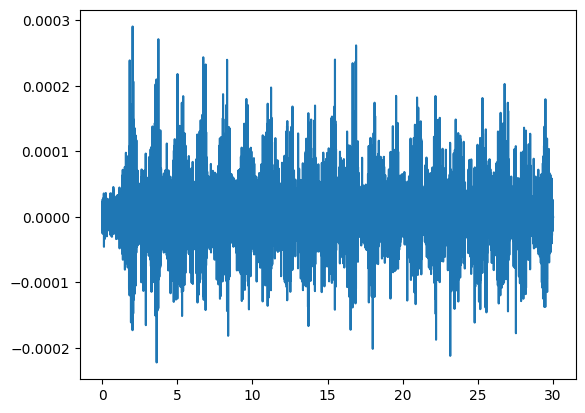

In [46]:
def bandpass_filter(signal, fs, lowcut=20, highcut=450, order=4):
    nyq = 0.5 *fs
    low = lowcut / nyq
    high = highcut/ nyq
    b,a = butter(order,[low,high], btype='band')
    filtered = filtfilt(b,a,signal)
    return filtered

emg_filtered = bandpass_filter(emg_muscle,fs)
plt.plot(time,emg_filtered)

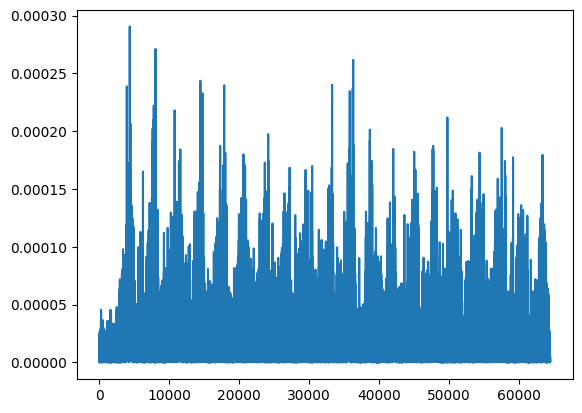

In [47]:
mag = np.abs(emg_filtered)
plt.plot(mag)

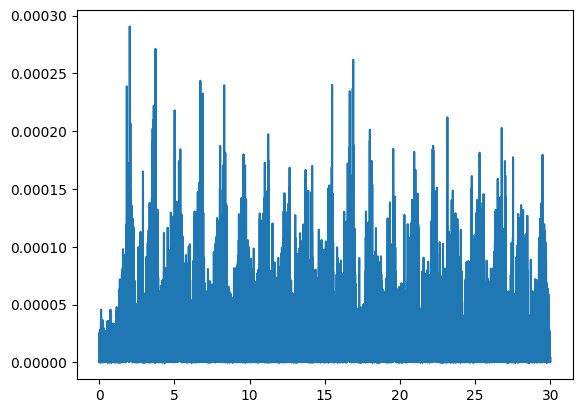

In [51]:
# same command
emg_rectified = np. abs(emg_filtered)
plt.plot(time,emg_rectified)

In [58]:
def lowpass_envelope(signal,fs, cutoff=10, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b,a = butter(order, normal_cutoff, btype='low')
    env = filtfilt(b, a, signal)
    return env
emg_env_smooth = lowpass_envelope(emg_rectified, fs, cutoff=10)

In [59]:
def rms_envelope(signal,fs,window_ms=50):
    window_size = int(fs * window_ms /1000)
    squared = signal**2
    window = np.ones(window_size) / window_size
    rms = np.sqrt(np.convolve(squared,window,mode='same'))
    return rms
emg_env = rms_envelope(emg_filtered, fs, window_ms=50)
    

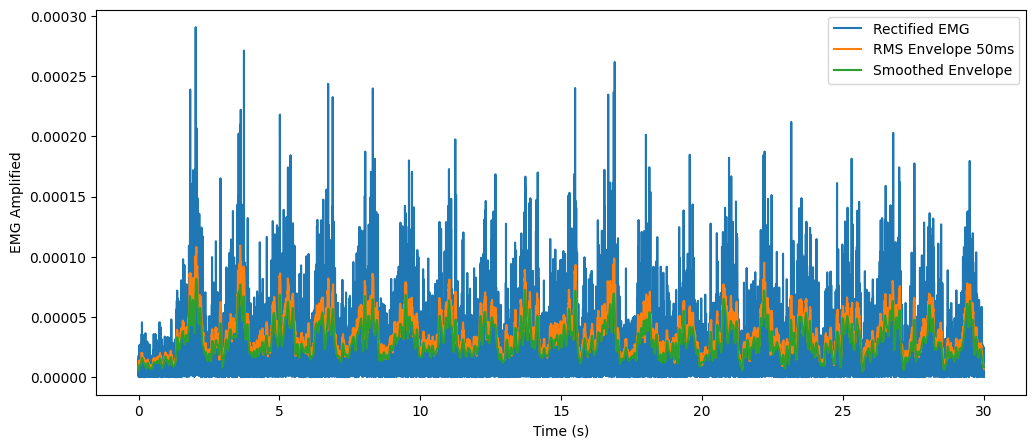

In [60]:
plt.figure(figsize=(12,5))
plt.plot(time,emg_rectified, label='Rectified EMG')
plt.plot(time,emg_env , label='RMS Envelope 50ms')
plt.plot(time,emg_env_smooth, label='Smoothed Envelope')
plt.xlabel("Time (s)")
plt.ylabel("EMG Amplified")
plt.legend()
plt.show()